<a href="https://colab.research.google.com/github/Arunya-123/Machine-learning-Repo/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Student Performance Prediction**

Student performance in exams can be influenced by factors such as **study** **hours, attendance, and previous marks.** In this project, the goal is to build a machine learning model that predicts a student’s exam score based on these factors. This project helps students understand how machine learning can be used to analyze data and make predictions.






In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.naive_bayes import GaussianNB


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [60]:
df=pd.read_csv('/content/student_performance_dataset.csv')
df

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass
...,...,...,...,...,...,...,...,...,...,...
703,S492,Male,14,84.658761,78,PhD,Yes,No,50,Fail
704,S301,Male,35,60.278990,83,Masters,No,No,62,Pass
705,S473,Male,25,98.384969,75,Bachelors,Yes,No,57,Fail
706,S307,Female,21,96.148012,84,Bachelors,Yes,No,65,Pass


In [61]:
df.shape

(708, 10)

In [62]:
df.columns

Index(['Student_ID', 'Gender', 'Study_Hours_per_Week', 'Attendance_Rate',
       'Past_Exam_Scores', 'Parental_Education_Level',
       'Internet_Access_at_Home', 'Extracurricular_Activities',
       'Final_Exam_Score', 'Pass_Fail'],
      dtype='object')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [64]:
df.isna().sum()

,0
Student_ID,0
Gender,0
Study_Hours_per_Week,0
Attendance_Rate,0
Past_Exam_Scores,0
Parental_Education_Level,0
Internet_Access_at_Home,0
Extracurricular_Activities,0
Final_Exam_Score,0
Pass_Fail,0


In [65]:
df.duplicated().sum()

np.int64(208)

In [66]:
df.groupby('Pass_Fail').size()

,0
Pass_Fail,
Fail,354
Pass,354


In [67]:
df.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


In [68]:
df.drop('Student_ID',axis=1, inplace=True)

In [69]:
for i in df.select_dtypes(include="object"):
 print(df[i].value_counts(),'\n')


Gender
Female    375
Male      333
Name: count, dtype: int64 

Parental_Education_Level
Bachelors      189
High School    183
Masters        171
PhD            165
Name: count, dtype: int64 

Internet_Access_at_Home
No     381
Yes    327
Name: count, dtype: int64 

Extracurricular_Activities
No     361
Yes    347
Name: count, dtype: int64 

Pass_Fail
Pass    354
Fail    354
Name: count, dtype: int64 



In [70]:
df = df.drop_duplicates()

print("New dataset shape:", df.shape)

New dataset shape: (500, 9)


<Axes: xlabel='Pass_Fail', ylabel='count'>

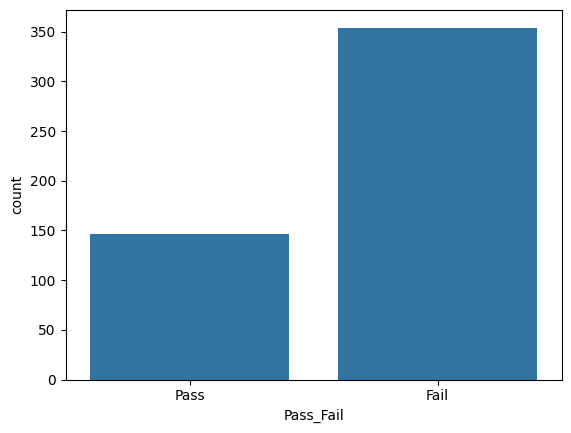

In [71]:
sns.countplot(x="Pass_Fail",data=df)

<Axes: xlabel='Pass_Fail', ylabel='Study_Hours_per_Week'>

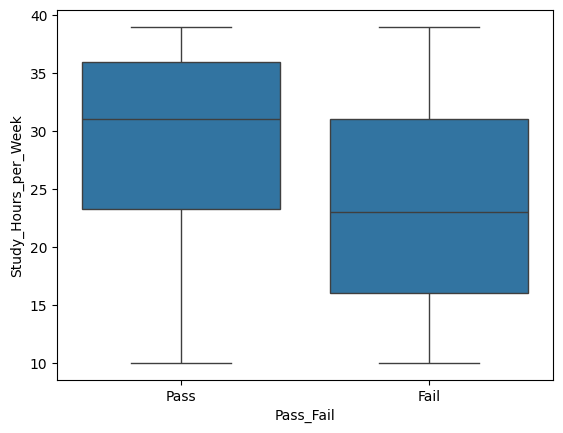

In [72]:
sns.boxplot(x="Pass_Fail",y="Study_Hours_per_Week",data=df)

<Axes: xlabel='Pass_Fail', ylabel='Attendance_Rate'>

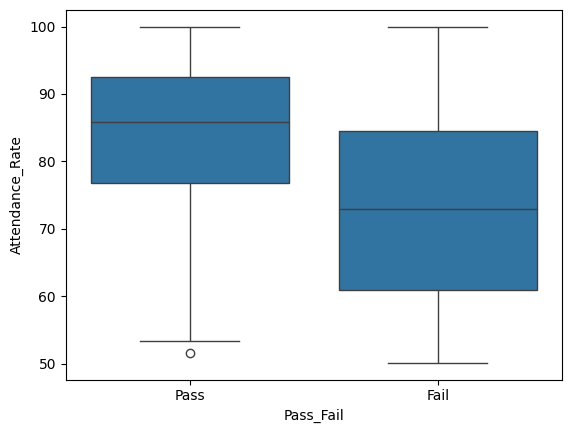

In [73]:
sns.boxplot(x="Pass_Fail",y="Attendance_Rate",data=df)

<Axes: xlabel='Pass_Fail', ylabel='Past_Exam_Scores'>

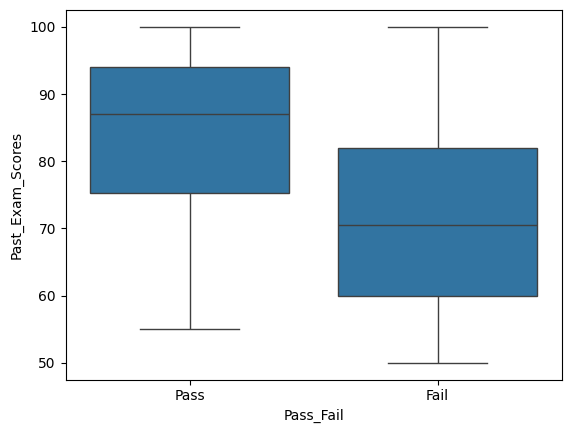

In [74]:
sns.boxplot(x="Pass_Fail",y="Past_Exam_Scores",data=df)


<Axes: xlabel='Pass_Fail', ylabel='Final_Exam_Score'>

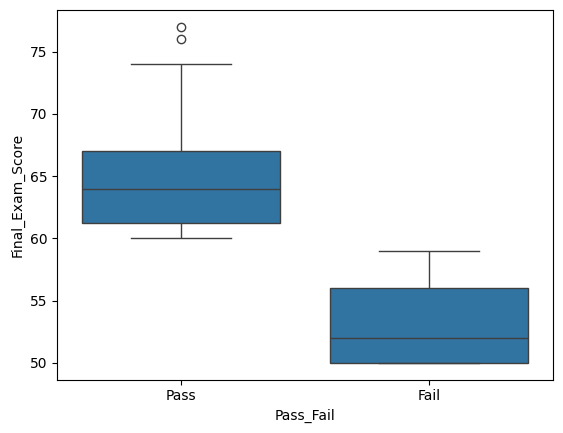

In [75]:
sns.boxplot(x="Pass_Fail",y="Final_Exam_Score", data=df)

<Axes: >

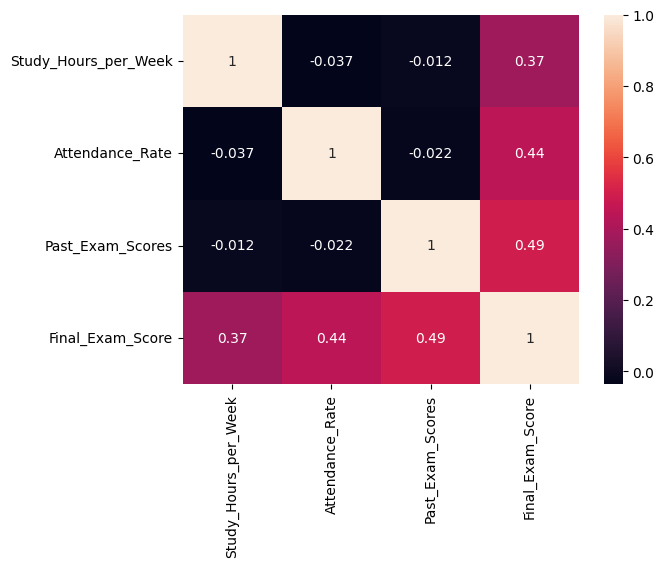

In [76]:
sns.heatmap(df.select_dtypes(include="number").corr(method= 'spearman'),annot=True)

In [77]:
#encoding
le=LabelEncoder()
for i in df.select_dtypes(include="object"):
  df[i]=le.fit_transform(df[i])
df

/tmp/ipykernel_222/3175045069.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i]=le.fit_transform(df[i])
/tmp/ipykernel_222/3175045069.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i]=le.fit_transform(df[i])
/tmp/ipykernel_222/3175045069.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,1,31,68.267841,86,1,1,1,63,1
1,1,16,78.222927,73,3,0,0,50,0
2,0,21,87.525096,74,3,1,0,55,0
3,0,27,92.076483,99,0,0,0,65,1
4,0,37,98.655517,63,2,0,1,70,1
...,...,...,...,...,...,...,...,...,...
701,0,21,69.858192,90,2,1,0,50,0
702,0,22,93.349688,76,0,0,0,60,1
703,1,14,84.658761,78,3,1,0,50,0
705,1,25,98.384969,75,0,1,0,57,0


In [78]:
X=df.drop("Pass_Fail",axis=1)
y=df["Pass_Fail"]

In [79]:
X_train,X_test,y_train,y_test=train_test_split(X,y)

In [80]:
X_train

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score
471,0,22,68.137895,87,3,0,0,54
374,1,22,84.149103,100,1,1,1,63
318,1,32,85.547624,97,0,0,1,64
132,0,12,78.874314,79,2,0,0,51
39,0,13,73.711865,77,3,1,1,55
...,...,...,...,...,...,...,...,...
110,1,24,62.536533,82,3,1,1,52
192,1,24,86.306042,91,1,1,1,65
622,0,27,79.497795,78,2,1,0,59
217,0,18,93.931456,81,0,0,1,57


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 707
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      500 non-null    int64  
 1   Study_Hours_per_Week        500 non-null    int64  
 2   Attendance_Rate             500 non-null    float64
 3   Past_Exam_Scores            500 non-null    int64  
 4   Parental_Education_Level    500 non-null    int64  
 5   Internet_Access_at_Home     500 non-null    int64  
 6   Extracurricular_Activities  500 non-null    int64  
 7   Final_Exam_Score            500 non-null    int64  
 8   Pass_Fail                   500 non-null    int64  
dtypes: float64(1), int64(8)
memory usage: 39.1 KB


In [56]:
X_train_scaled.shape

(375, 8)

In [92]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [93]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        98
           1       1.00      1.00      1.00        27

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125


Confusion Matrix:
 [[98  0]
 [ 0 27]]


<Axes: >

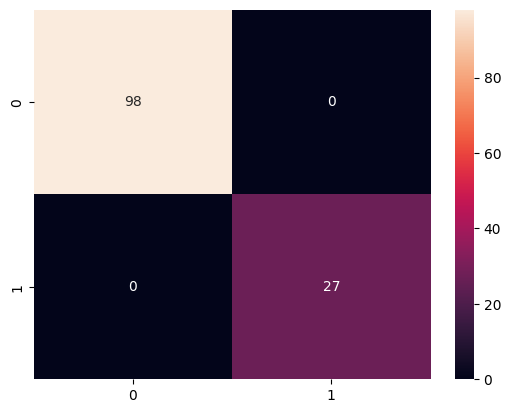

In [99]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [97]:
tree1 = tree.DecisionTreeClassifier()
tree1.fit(X_train, y_train)
y_pred1=tree1.predict(X_test)

<Axes: >

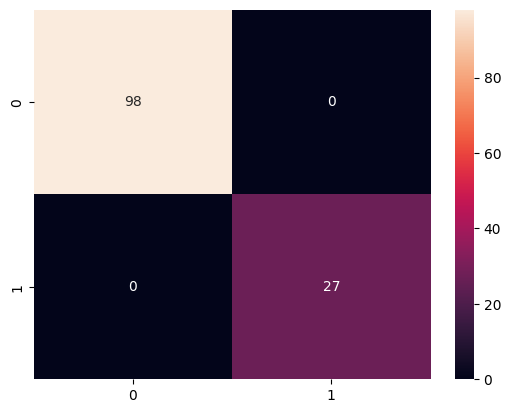

In [98]:
sns.heatmap(confusion_matrix(y_test,y_pred1),annot=True)

In [100]:
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        98
           1       1.00      1.00      1.00        27

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



In [103]:
neigh = KNeighborsClassifier()
neigh.fit(X_train, y_train)
y_pred3=neigh.predict(X_test)

In [104]:
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("\nClassification Report:\n", classification_report(y_test, y_pred3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred3))

Accuracy: 0.952

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        98
           1       0.92      0.85      0.88        27

    accuracy                           0.95       125
   macro avg       0.94      0.92      0.93       125
weighted avg       0.95      0.95      0.95       125


Confusion Matrix:
 [[96  2]
 [ 4 23]]


In [117]:
neigh1 = KNeighborsClassifier(n_neighbors=7)
neigh1.fit(X_train, y_train)
y_pred4=neigh1.predict(X_test)

In [118]:
print("Accuracy:", accuracy_score(y_test, y_pred4))
print("\nClassification Report:\n", classification_report(y_test, y_pred4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred4))

Accuracy: 0.96

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        98
           1       0.96      0.85      0.90        27

    accuracy                           0.96       125
   macro avg       0.96      0.92      0.94       125
weighted avg       0.96      0.96      0.96       125


Confusion Matrix:
 [[97  1]
 [ 4 23]]


In [115]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred5=gnb.predict(X_test)

In [116]:
print("Accuracy:", accuracy_score(y_test, y_pred5))
print("\nClassification Report:\n", classification_report(y_test, y_pred5))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred5))

Accuracy: 0.968

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98        98
           1       0.90      0.96      0.93        27

    accuracy                           0.97       125
   macro avg       0.94      0.97      0.95       125
weighted avg       0.97      0.97      0.97       125


Confusion Matrix:
 [[95  3]
 [ 1 26]]


In [119]:
models=["logistic regression","DecisionTreeClassifier","KNeighborsClassifier k=5","KNeighborsClassifier k=7","naive_bayes"]
accuracy=[1,1,0.952,0.96,0.968]
pd. DataFrame({"models":models,"Accuracy":accuracy})

,models,Accuracy
0,logistic regression,1.000
1,DecisionTreeClassifier,1.000
2,KNeighborsClassifier k=5,0.952
3,KNeighborsClassifier k=7,0.960
4,naive_bayes,0.968


In the Student Performance Prediction model, Logistic Regression and Decision Tree achieved an accuracy score of 1. This indicates that the models can predict unseen data perfectly.

KNN produced different prediction results for different values of k.

There is no issue of multicollinearity in the dataset, and the dependent feature shows a good correlation with the independent features, which leads to a high prediction score.